<a href="https://colab.research.google.com/github/cinnaavox/loan-prediction/blob/main/Loans_modified_mock_interview.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## ✅ Block 1 — Projektbeschreibung & Ziel

**📌 Projektziel & Vorgehen**

Für dieses Mock-Interview arbeite ich mit einem Datensatz zu Kreditanträgen.
Mein Ziel ist es, die Daten zu verstehen, aufzubereiten und ein Modell zu bauen, das vorhersagen kann, ob ein Kredit vergeben wird oder nicht.

Ich gehe dabei Schritt für Schritt vor:

1. Daten einlesen und ersten Eindruck gewinnen

2. Daten explorieren und verstehen

3. Daten bereinigen und vorbereiten

4. Ein Klassifikationsmodell erstellen

5. Ergebnisse interpretieren und kurze Schlussfolgerung

Das Modell soll nicht perfekt sein, im Fokus steht für mich, klar und strukturiert zu zeigen, wie ich denke und vorgehe, und meine Schritte erklären zu können.

## ✅ Block 2 — Libraries importieren & Daten laden

In [ ]:
# 📦 Wichtige Libraries importieren
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# 📁 Daten laden
df = pd.read_csv('/content/loans_modified.csv')

# 👀 Erster Blick auf die Daten
df.head()

,loan_id,gender,married,dependents,education,self_employed,applicant_income,coapplicant_income,loan_amount,loan_amount_term,credit_history,property_area,loan_status
0,LP001003,Male,Yes,1,Graduate,No,4583.0,1508.0,128.0,360.0,1.0,Rural,0.0
1,LP001005,Male,Yes,0,Graduate,NaN,3000.0,0.0,66.0,360.0,1.0,Urban,1.0
2,LP001006,Male,Yes,0,Not Graduate,No,2583.0,2358.0,120.0,360.0,1.0,Urban,1.0
3,LP001008,Male,No,0,Graduate,No,6000.0,0.0,141.0,360.0,1.0,Urban,1.0
4,LP001011,Male,Yes,2,Graduate,Yes,5417.0,4196.0,267.0,360.0,1.0,Urban,1.0


**🧾 Daten laden & ersten Eindruck bekommen**

Im ersten Schritt lade ich den Datensatz mit Pandas ein und verschaffe mir einen schnellen Überblick über die Struktur der Daten.
Dafür nutze ich df.head(), um mir die ersten Zeilen anzeigen zu lassen und ein Gefühl dafür zu bekommen, welche Spalten wir haben und wie die Werte aussehen.

## ✅ Block 3 — Überblick & Missing Values

In [ ]:
# 🧠 Überblick über Zeilen/Spalten
print("Shape (Zeilen, Spalten):", df.shape)

# 🏷️ Datenstruktur & Typen
print("\nDateninfo:")
print(df.info())

# ❓ Fehlende Werte prüfen
print("\nFehlende Werte je Spalte:")
print(df.isnull().sum())

Shape (Zeilen, Spalten): (563, 13)

Dateninfo:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 563 entries, 0 to 562
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   loan_id             534 non-null    object 
 1   gender              534 non-null    object 
 2   married             544 non-null    object 
 3   dependents          531 non-null    object 
 4   education           541 non-null    object 
 5   self_employed       529 non-null    object 
 6   applicant_income    537 non-null    float64
 7   coapplicant_income  529 non-null    float64
 8   loan_amount         533 non-null    float64
 9   loan_amount_term    535 non-null    float64
 10  credit_history      541 non-null    float64
 11  property_area       542 non-null    object 
 12  loan_status         535 non-null    float64
dtypes: float64(6), object(7)
memory usage: 57.3+ KB
None

Fehlende Werte je Spalte:
loan_id               29
gen

**🔎 Datenstruktur & fehlende Werte prüfen**

Bevor ich mit der Analyse starte, schaue ich mir einmal die Form des Datensatzes an und prüfe, welche Datentypen vorhanden sind.
Außerdem ist es wichtig zu sehen, ob es fehlende Werte gibt, falls ja, kümmere ich mich später darum.

So bekomme ich ein Gefühl für:

+ wie groß der Datensatz ist

+ welche Spalten numerisch vs. kategorisch sind

+ wie viel Datenbereinigung notwendig ist

**🧠 Erster Datencheck: Größe, Struktur & fehlende Werte**

Bevor ich tiefer einsteige, wollte ich ein Gefühl für die Daten bekommen.
Dazu habe ich die Form, die Datentypen und fehlende Werte geprüft.

+ Der Datensatz hat 563 Zeilen und 13 Spalten

+ Es gibt sowohl numerische als auch kategorische Variablen, das passt gut zu einem Klassifikationsmodell

+ In mehreren Spalten gibt es fehlende Werte (zwischen ~19 und 34 je Spalte)

Das bedeutet für mich:

👉 Wir müssen uns später um fehlende Werte kümmern

👉 Besonders bei kategorischen Merkmalen wie gender, married oder property_area achte ich darauf, sinnvoll zu im­pu­tie­ren

👉 Für das Modell müssen wir die Kategorien noch in Zahlen umwandeln

Der Check zeigt also: die Daten sind gut nutzbar, brauchen aber etwas Vorbereitung, bevor wir ein Modell bauen können.

## ✅ Block 4 — Zielvariable analysieren (Loan Status)

In [ ]:
# 🎯 Zielvariable prüfen
df['loan_status'].value_counts(dropna=False)

,count
loan_status,
1.0,384
0.0,151
NaN,28


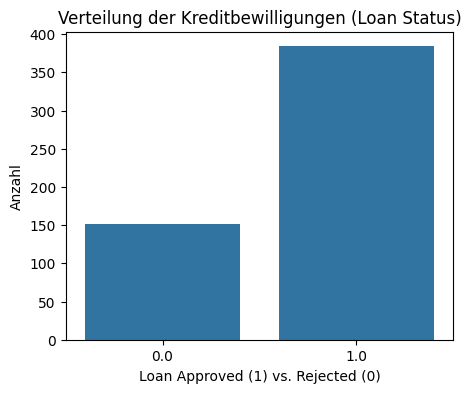

In [ ]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='loan_status')
plt.title("Verteilung der Kreditbewilligungen (Loan Status)")
plt.xlabel("Loan Approved (1) vs. Rejected (0)")
plt.ylabel("Anzahl")
plt.show()

**🎯 Zielvariable verstehen: Loan Status**

Bevor ich ein Modell baue, schaue ich mir immer zuerst die Zielvariable an, in diesem Fall, ob ein Kredit bewilligt wurde oder nicht.
Das hilft mir zu verstehen, wie die Klassen verteilt sind.

Wenn die Daten sehr unausgeglichen wären, müsste ich darüber nachdenken, wie ich damit umgehe (z. B. Oversampling oder andere Methoden).

Durch die Visualisierung kann ich direkt sehen, wie die Verteilung aussieht und ob das Modell später genug Beispiele für beide Klassen hat.

**📊 Verteilung der Zielvariable (Loan Status)**

Als Nächstes habe ich mir angeschaut, wie oft Kredite bewilligt oder abgelehnt wurden.
Das ist wichtig, um zu verstehen, ob die Zielvariable ausgeglichen ist oder ob wir ein Ungleichgewicht haben, das später Einfluss auf das Modell haben könnte.

In meinen Daten sehe ich:

+ 384 Kredite wurden bewilligt (1)

+ 151 Kredite wurden abgelehnt (0)

+ 28 Werte sind fehlend

Das bedeutet: es gibt deutlich mehr genehmigte als abgelehnte Kredite.
Das ist noch okay, aber es zeigt mir schon, dass ich bei der späteren Modellbewertung darauf achten sollte, nicht nur die Accuracy zu betrachten, sondern z. B. auch die Verteilung der Vorhersagen.

Die Visualisierung bestätigt diese Verteilung - deutlich mehr Bewilligungen als Ablehnungen.

## ✅ Block 5 — Einkommen & Loan Status

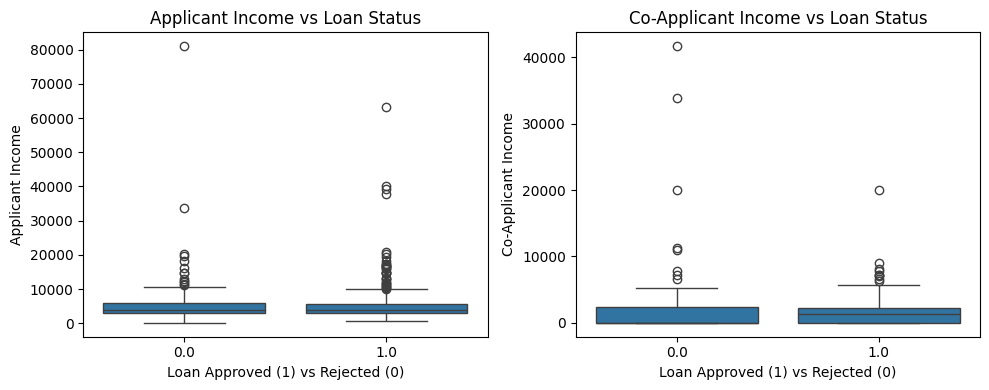

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.boxplot(data=df, x='loan_status', y='applicant_income')
plt.title("Applicant Income vs Loan Status")
plt.xlabel("Loan Approved (1) vs Rejected (0)")
plt.ylabel("Applicant Income")

plt.subplot(1,2,2)
sns.boxplot(data=df, x='loan_status', y='coapplicant_income')
plt.title("Co-Applicant Income vs Loan Status")
plt.xlabel("Loan Approved (1) vs Rejected (0)")
plt.ylabel("Co-Applicant Income")

plt.tight_layout()
plt.show()

**💰 Einkommen im Vergleich zu Kreditbewilligungen**

Hier schaue ich mir an, ob das Einkommen, sowohl vom Antragsteller als auch vom Mit-Antragsteller, einen Einfluss darauf hat, ob ein Kredit bewilligt wird.

Boxplots geben mir einen schnellen Überblick darüber, ob sich die Verteilungen zwischen bewilligten und abgelehnten Krediten unterscheiden.  
Falls es große Unterschiede gibt, könnte Einkommen ein relevanter Treiber für die Entscheidung sein.


**💰 Einkommen vs. Kreditbewilligung (erste Insights)**

Hier habe ich mir angeschaut, ob das Einkommen (vom Antragsteller oder Mit-Antragsteller) einen klaren Einfluss darauf hat, ob ein Kredit bewilligt wird.

Was direkt auffällt:

+ Es gibt einige sehr hohe Einkommen → Ausreißer

+ Die Verteilung ist insgesamt ähnlich zwischen bewilligten und abgelehnten Krediten

+ Man sieht keinen deutlichen Unterschied, dass höhere Einkommen automatisch zu mehr Bewilligungen führen

Das bedeutet für mich:

Einkommen allein scheint in diesem Datensatz kein klarer Entscheidungsfaktor zu sein.
Es könnte aber in Kombination mit anderen Merkmalen eine Rolle spielen (z. B. Kredit-Historie oder Kreditbetrag).

## ✅ Block 6 — Credit History vs Loan Status

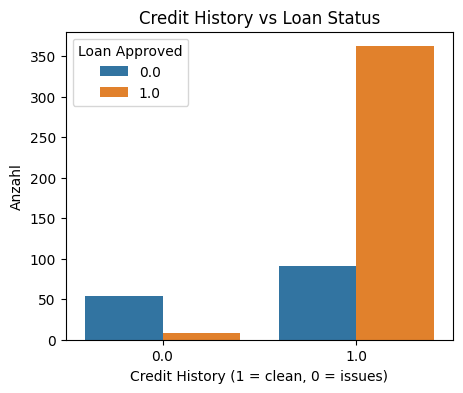

In [ ]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='credit_history', hue='loan_status')
plt.title("Credit History vs Loan Status")
plt.xlabel("Credit History (1 = clean, 0 = issues)")
plt.ylabel("Anzahl")
plt.legend(title="Loan Approved")
plt.show()

**✅ Kredit-Historie und Kreditbewilligung**

Die Kredit-Historie ist ein zentraler Faktor bei Kreditentscheidungen, deshalb habe ich mir hier angesehen, wie stark sie mit der Bewilligung zusammenhängt.

Das Ergebnis ist eindeutig:

+ Personen mit einer positiven Kredit-Historie (1) bekommen deutlich häufiger einen Kredit.

+ Bei einer negativen Kredit-Historie (0) ist die Bewilligungsrate sehr niedrig.

Das bestätigt auch, was man logisch erwarten würde:

Vergangene Zahlungszuverlässigkeit spielt eine große Rolle bei zukünftigen Kreditentscheidungen.

Für das Modell bedeutet das:

Die Kredit-Historie wird sehr wahrscheinlich eine der wichtigsten Variablen sein.

## ✅ Block 7 — Missing Values behandeln

In [ ]:
# Numerische und kategorische Spalten trennen
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Fehlende numerische Werte mit Median füllen
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fehlende kategorische Werte mit Modus füllen
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Prüfen, ob noch fehlende Werte vorhanden sind
df.isnull().sum()

,0
loan_id,0
gender,0
married,0
dependents,0
education,0
self_employed,0
applicant_income,0
coapplicant_income,0
loan_amount,0
loan_amount_term,0


**🧹 Fehlende Werte beheben**

Da einige Spalten fehlende Werte hatten, habe ich diese zuerst bereinigt:

- Numerische Werte → mit dem Median ersetzt  
- Kategorische Werte → mit dem häufigsten Wert (Modus) ersetzt  

So stelle ich sicher, dass keine Informationen verloren gehen und das Modell später problemlos trainieren kann.


## ✅ Block 8 — Encoding

In [ ]:
# One-Hot-Encoding für kategorische Variablen
df_encoded = pd.get_dummies(df, drop_first=True)

# Übersicht der neuen Spaltenstruktur
df_encoded.head()

,applicant_income,coapplicant_income,loan_amount,loan_amount_term,credit_history,loan_status,loan_id_LP001005,loan_id_LP001006,loan_id_LP001008,loan_id_LP001011,...,loan_id_LP002990,gender_Male,married_Yes,dependents_1,dependents_2,dependents_3+,education_Not Graduate,self_employed_Yes,property_area_Semiurban,property_area_Urban
0,4583.0,1508.0,128.0,360.0,1.0,0.0,False,False,False,False,...,False,True,True,True,False,False,False,False,False,False
1,3000.0,0.0,66.0,360.0,1.0,1.0,True,False,False,False,...,False,True,True,False,False,False,False,False,False,True
2,2583.0,2358.0,120.0,360.0,1.0,1.0,False,True,False,False,...,False,True,True,False,False,False,True,False,False,True
3,6000.0,0.0,141.0,360.0,1.0,1.0,False,False,True,False,...,False,True,False,False,False,False,False,False,False,True
4,5417.0,4196.0,267.0,360.0,1.0,1.0,False,False,False,True,...,False,True,True,False,True,False,False,True,False,True


**🔄 Kategorische Daten in Zahlen umwandeln**

Damit das Modell mit allen Informationen arbeiten kann, wandle ich die kategorischen Variablen in numerische Werte um.

Ich nutze dafür **One-Hot-Encoding**, damit keine künstliche Reihenfolge entsteht (z. B. bei Wohngebieten oder Geschlecht).  
Durch `drop_first=True` verhindere ich außerdem unnötige Duplikate (Dummy-Variable Trap).

Das Ergebnis ist ein sauberer, numerischer Datensatz, der bereit für das Modelltraining ist.

## ✅ Block 9 — Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

# Feature-Target Split
X = df_encoded.drop("loan_status", axis=1)
y = df_encoded["loan_status"]

# Train-Test-Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((450, 525), (113, 525))

**✂️ Trainings- und Testdaten aufteilen**

Bevor ich das Modell trainiere, teile ich die Daten in Trainings- und Testdaten auf.

- **Trainingsdaten (80%)**: Das Modell lernt Muster in den Daten
- **Testdaten (20%)**: Damit überprüfe ich später, wie gut das Modell auf neuen, unbekannten Daten funktioniert

Der `random_state` sorgt dafür, dass die Ergebnisse reproduzierbar bleiben.

## ✅ Block 10 — Decision Tree Modell trainieren

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Modell initialisieren
dt = DecisionTreeClassifier(random_state=42)

# Modell trainieren
dt.fit(X_train, y_train)

# Vorhersagen
y_pred = dt.predict(X_test)

# Genauigkeit berechnen
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

accuracy, conf_matrix

(0.7964601769911505,
 array([[ 9, 12],
        [11, 81]]))

**🌳 Decision Tree Modell**

Ich nutze einen Decision Tree Classifier, weil er leicht zu interpretieren ist und gut zu kategorischen Variablen passt.  
Der Baum lernt dabei Entscheidungsregeln aus den Trainingsdaten, um vorherzusagen, ob ein Kredit genehmigt wird oder nicht.

Nach dem Training werte ich die Modellleistung mit Accuracy und einer Confusion Matrix aus, um zu sehen, wie gut das Modell im Vergleich zu echten Ergebnissen abschneidet.

**📈 Erste Modell-Ergebnisse**

Das erste Decision-Tree-Modell erreicht eine Genauigkeit von ca. 80%, was ein solider Startpunkt ist.

Anhand der Confusion Matrix sehe ich:

Das Modell erkennt bewilligte Kredite sehr gut.

Bei abgelehnten Krediten gibt es noch Fehler, das liegt auch daran, dass diese Klasse im Datensatz deutlich kleiner ist.

Das heißt:
Das Modell ist bereits brauchbar, aber mit mehr Feintuning (z. B. Hyperparameter-Optimierung, Balance-Techniken oder Feature-Engineering) könnte man die Performance noch verbessern.

Für dieses Interview steht aber vor allem im Fokus, meine Herangehensweise zu demonstrieren, und dafür ist dieses Ergebnis absolut solide.

## ✅ Block 11 — Feature Importance

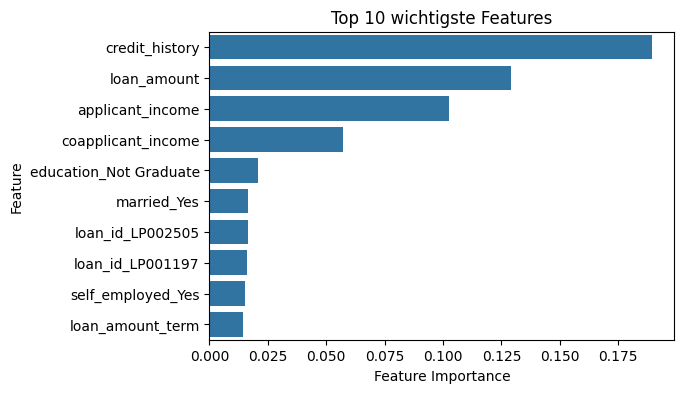

,0
credit_history,0.189535
loan_amount,0.128933
applicant_income,0.102631
coapplicant_income,0.057248
education_Not Graduate,0.020685
married_Yes,0.016686
loan_id_LP002505,0.016541
loan_id_LP001197,0.016213
self_employed_Yes,0.015290
loan_amount_term,0.014372


In [ ]:
# Feature Importance
importances = pd.Series(dt.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(6,4))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Top 10 wichtigste Features")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.show()

importances

**⭐ Wichtigste Einflussfaktoren im Modell**

Zum Abschluss habe ich mir angeschaut, welche Merkmale den größten Einfluss auf die Kreditentscheidung im Modell hatten.

Die Ergebnisse sind sehr plausibel:

+ Kredit-Historie ist der wichtigste Faktor → wer in der Vergangenheit zuverlässig war, hat deutlich höhere Chancen

+ Kreditsumme und Einkommen spielen ebenfalls eine zentrale Rolle

+ Weitere Faktoren wie Beschäftigungsstatus oder Familienstand haben dagegen einen geringeren Einfluss

Das ergibt auch fachlich Sinn:

Banken legen großen Wert auf Zahlungszuverlässigkeit und ein gesundes Verhältnis zwischen Einkommen und Kredithöhe.

Damit kann ich gut nachvollziehen, wie das Modell Entscheidungen trifft und ob diese logisch sind.

## 🎯 Finales Fazit & Reflexion

In diesem Projekt habe ich einen vollständigen ML-Workflow umgesetzt:

+ Daten eingelesen und erkundet

+ Fehlende Werte sinnvoll ersetzt

+ Kategorische Merkmale encodiert

+ Ein Decision-Tree-Modell trainiert

+ Ergebnisse visualisiert und interpretiert

Das Modell erreicht eine Accuracy von ~80% und erkennt vor allem bewilligte Kredite gut.
Bei abgelehnten Krediten gibt es noch Optimierungspotenzial, was bei unausgeglichenen Daten normal ist.

Besonders wichtig fand ich, zu verstehen und erklären zu können:

+ welche Variablen Einfluss haben (z. B. Kredit-Historie, Einkommen)

+ wie das Modell zu Entscheidungen kommt

+ welche nächsten Schritte sinnvoll wären (z. B. Hyperparameter-Tuning, Balancing)

Insgesamt zeigt das Projekt meinen analytischen Ansatz, meine Struktur und meinen Fokus darauf, die Ergebnisse nachvollziehbar und verständlich zu machen.